> # Courbes planes: courbure

> On propose quelques calculs et tracés de la courbure d'une courbe.

> ## Trochoïdes

> Les trochoïdes sont une famille de courbes qui généralisent la cycloïde.
>
> Référence: article "Trochoïde" sur Wikipédia: https://fr.wikipedia.org/wiki/Trochoïde


In [1]:
def trochoide(a, b):
    r"""
    Renvoie la trochoïde de paramètres ``a`` et ``b``.

    REFERENCES::

    - Article "Trochoïde" sur Wikipedia-fr:
      https://fr.wikipedia.org/wiki/Trochoïde

    EXAMPLES:

    La cycloïde de rayon 1::

        sage: M = trochoide(1, 1)
        sage: M
        t |--> (t - sin(t), -cos(t) + 1)
    """
    c(t) = (a * t - b * sin(t), a - b * cos(t))
    return c

> **Exercice.**
>
> Pour chacune des trochoïdes illustrées dans l'article Wikipédia,
> reproduire le tracé.

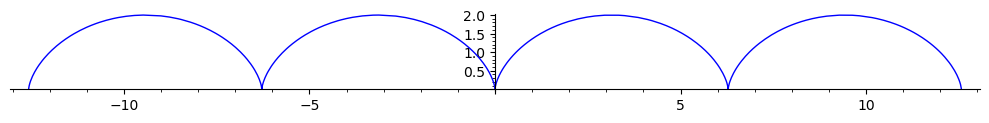

In [2]:
A = trochoide(1,1)
Courbe_A = parametric_plot(A,(-4*pi,4*pi), color = 'blue')
Courbe_A.show(figsize = 10, aspect_ratio = 1)

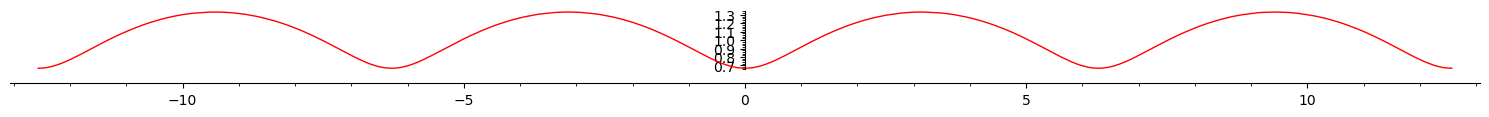

In [3]:
B = trochoide(1,1/3)
Courbe_B = parametric_plot(B,(-4*pi,4*pi),color = 'red')
Courbe_B.show(figsize = 15, aspect_ratio = 1.5)

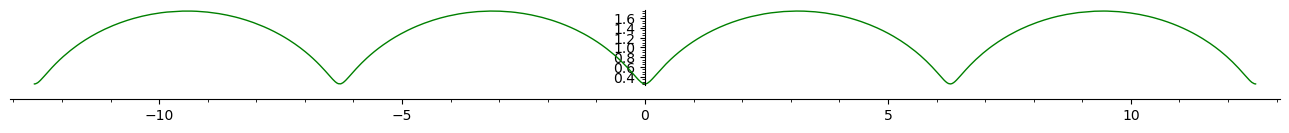

In [4]:
C1 = trochoide(1,3/4)
Courbe_C1 = parametric_plot(C1,(-4*pi,4*pi),color = 'green')
Courbe_C1.show(figsize = 13, aspect_ratio = 1)

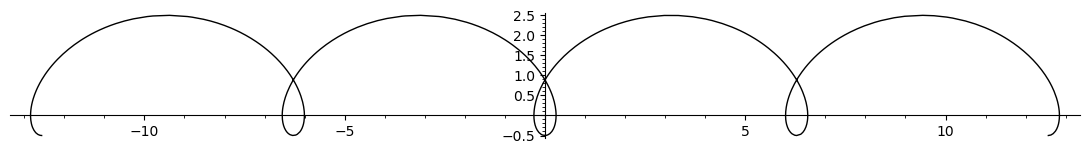

In [6]:
D = trochoide(1,1.5)
Courbe_D = parametric_plot(D,(-4*pi,4*pi),color = 'black')
Courbe_D.show(figsize = 11)

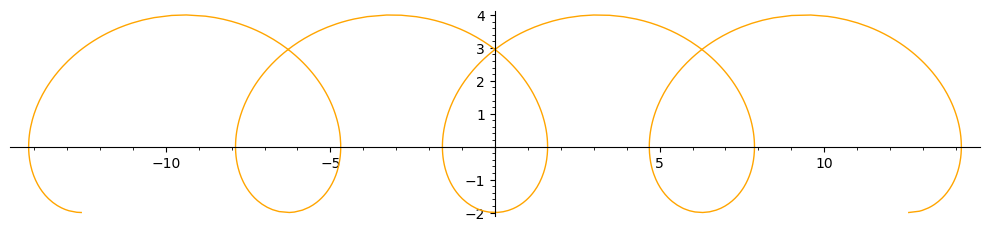

In [5]:
E = trochoide(1,3)
Courbe_E = parametric_plot(E,(-4*pi,4*pi), color = 'orange')
Courbe_E.show(figsize = 10)

> ## Courbure

> On fournit un fichier auxiliaire `courbes_planes.sage` contenant la définition de la courbure.

In [7]:
# Exécuter cette cellule pour exécuter les commandes contenues dans le fichier `courbes_planes.sage`.

%runfile courbes_planes.sage

> On voudrait tracer la courbure algébrique des différentes
> trochoïdes de l'article Wikipédia.
>
> Voici un exemple pour la cycloïde.


In [8]:
M = trochoide(1, 1)
k = courbure_algebrique(M)

In [9]:
k

t |--> -((cos(t) - 1)*cos(t) + sin(t)^2)/((cos(t) - 1)^2 + sin(t)^2)^(3/2)

On remarque que la courbure contient beaucoup de fonctions trigonométriques.

On peut essayer de simplifier son expression avec la méthode `simplify_trig`.

In [10]:
k1(t) = k(t).simplify_trig()
k1

t |--> -1/2/sqrt(-2*cos(t) + 2)

Il reste une racine carrée et on peut utiliser
l'identité $\cos(2 a) = 1 - 2 \sin^2(a)$.

In [11]:
k2(t) = k1(t).subs({cos(t): 1 - 2*sin(t/2)^2})
k2

t |--> -1/4/sqrt(sin(1/2*t)^2)

Déclarons `t` comme variable réelle pour permettre
de simplifier la racine carrée du carré.

In [12]:
t = SR.var('t', domain='real')
k3(t) = k2(t).simplify_full()
k3

t |--> -1/4/abs(sin(1/2*t))

Traçons la courbure en fonction du temps.

Avec `ticks`, on choisit ici la position des graduations
sur l'axe des `x` et on laisse libre celles sur l'axe
des ordonnées. On indique aussi avec `tick_formatter`
d'utiliser des multiples de π pour les libellés des
graduations de l'axe des abscisses.

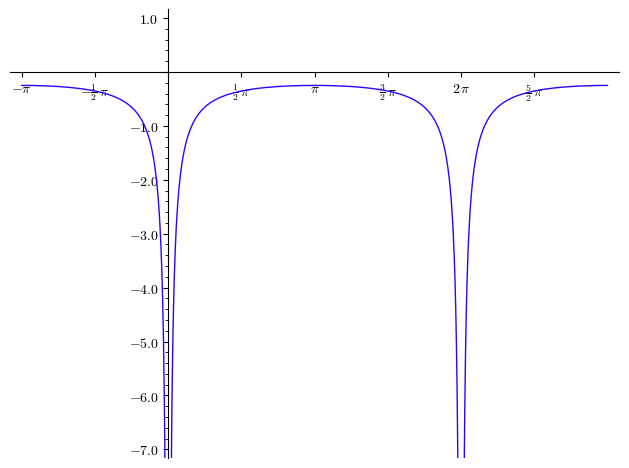

In [13]:
plot(k3, (-π, 3*π), xmin=-1, xmax=7, ymin=-7, ymax=1, hue=0.7,
     ticks=[srange(-pi, 3*pi, pi/2), None], tick_formatter=pi)

## Exercices

> **Exercice.**
>
> En utilisant la fonction `courbure_algebrique` fournie dans le
> fichier `courbes_planes.sage`, tracer la courbure algébrique des
> différentes trochoïdes de l'article Wikipédia en fonction du temps.



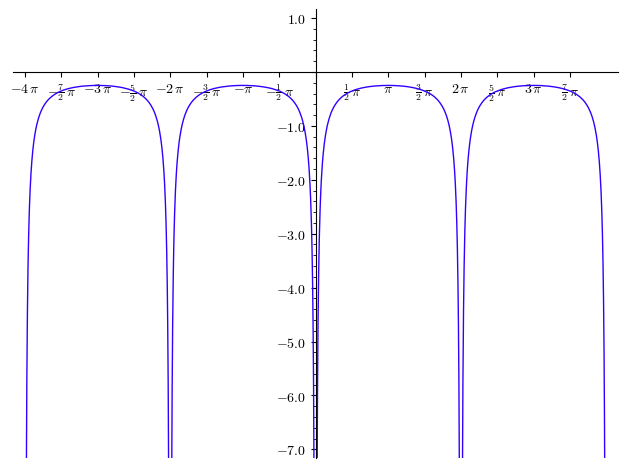

In [14]:
def courbure_algebrique(M):
    r"""
    Renvoie la courbure algébrique comme fonction du temps.
    """
    M1 = derivee_vectorielle(M)  # dérivée première
    M2 = derivee_vectorielle(M1)  # dérivée seconde
    courbure(t) = M2(t)*J(M1(t))/M1(t).norm().simplify()^3
    return courbure

plot(courbure_algebrique(A),(-4*pi,4*pi), xmin = 1, xmax = 7, ymin = -7, ymax = 1, hue=0.7
    , ticks=[srange(-4*pi, 4*pi, pi/2), None], tick_formatter=pi)

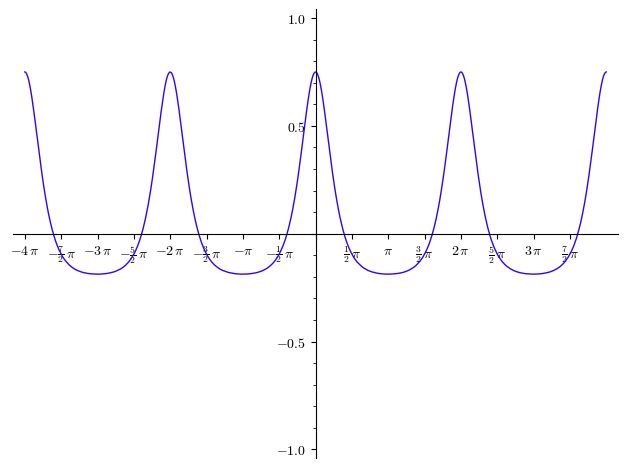

In [15]:
plot(courbure_algebrique(B),(-4*pi,4*pi), xmin = 1, xmax = 1, ymin = -1, ymax = 1, hue=0.7
    , ticks=[srange(-4*pi, 4*pi, pi/2), None], tick_formatter=pi)

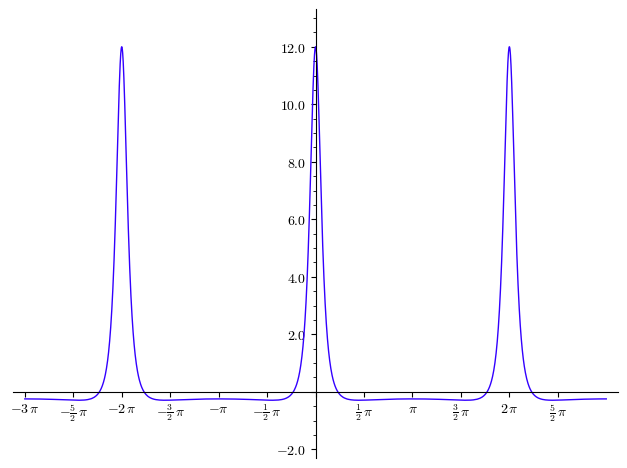

In [16]:
plot(courbure_algebrique(C1),(-3*pi,3*pi), xmin = 1, xmax = 7, ymin = -2, ymax = 13, hue=0.7
    , ticks=[srange(-3*pi, 3*pi, pi/2), None], tick_formatter=pi)

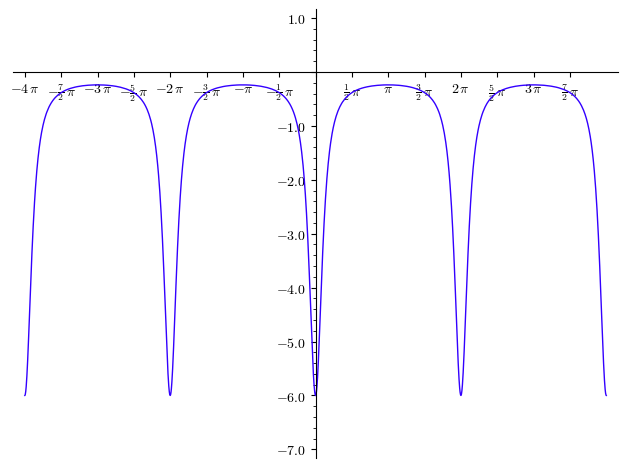

In [17]:
plot(courbure_algebrique(D),(-4*pi,4*pi), xmin = 1, xmax = 7, ymin = -7, ymax = 1, hue=0.7
    , ticks=[srange(-4*pi, 4*pi, pi/2), None], tick_formatter=pi)

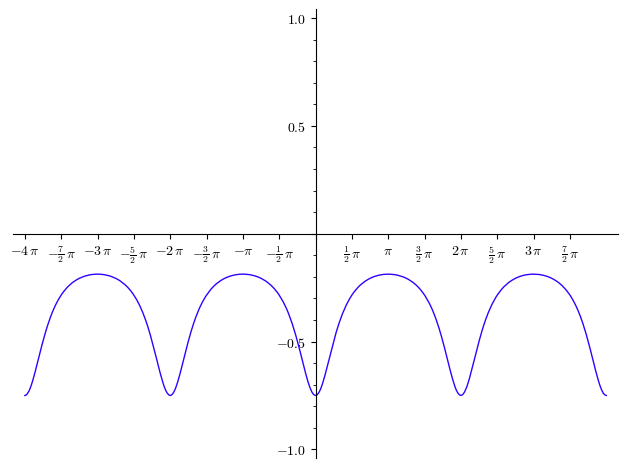

In [18]:
plot(courbure_algebrique(E),(-4*pi,4*pi), xmin = 1, xmax = 7, ymin = -1, ymax = 1, hue=0.7
    , ticks=[srange(-4*pi, 4*pi, pi/2), None], tick_formatter=pi)

> **Exercice.**
>
> Pour chacune des trochoïdes, tracer le point $M(π/2)$ et le cercle osculateur en ce point.
>
> On pourra aussi tracer en gris plusieurs cercles tangents en ce point,
> et tracer le cercle osculateur d'une autre couleur.



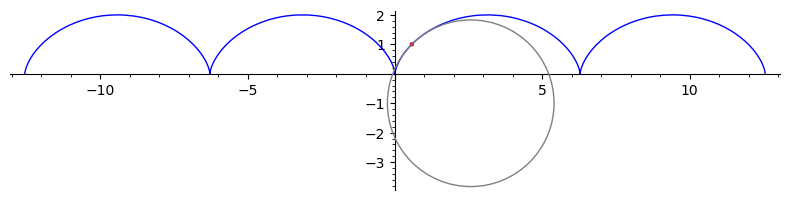

In [19]:
teta = pi/2
Mteta = A(teta)
v = derivee_vectorielle(A)
vteta = v(teta)
Tteta = vteta/vteta.norm()
Nteta = J(Tteta)
k = courbure_algebrique(A)
kteta = k(teta)
rteta = 1/kteta

C_A = Mteta + rteta * Nteta

Cercle_A = parametric_plot(A,(t, -4*pi,4*pi)) + circle(C_A,abs(rteta), color='grey') + point(A(pi/2), color = 'red')
Cercle_A.show(figsize = 8)

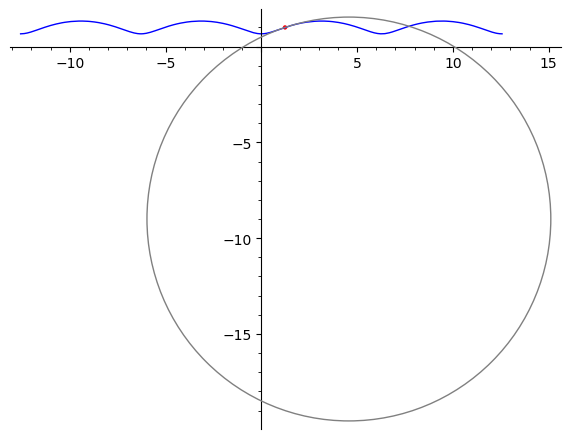

In [20]:
teta = pi/2
Mteta = B(teta)
v = derivee_vectorielle(B)
vteta = v(teta)
Tteta = vteta/vteta.norm()
Nteta = J(Tteta)
k = courbure_algebrique(B)
kteta = k(teta)
rteta = 1/kteta

C_B = Mteta + rteta * Nteta

Cercle_B = parametric_plot(B,(t, -4*pi,4*pi)) + circle(C_B,abs(rteta), color='grey') + point(B(pi/2), color = 'red')
Cercle_B.show(figsize = 6)

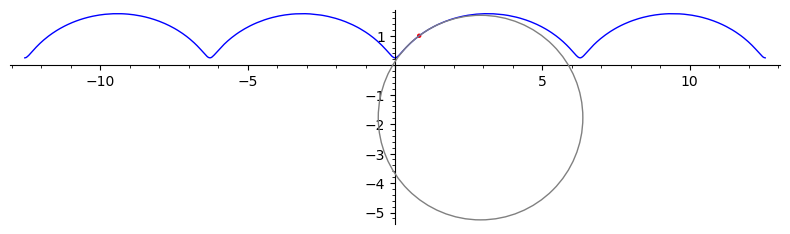

In [21]:
teta = pi/2
Mteta = C1(teta)
v = derivee_vectorielle(C1)
vteta = v(teta)
Tteta = vteta/vteta.norm()
Nteta = J(Tteta)
k = courbure_algebrique(C1)
kteta = k(teta)
rteta = 1/kteta

C_C = Mteta + rteta * Nteta

Cercle_C1 = parametric_plot(C1,(t, -4*pi,4*pi)) + circle(C_C,abs(rteta), color='grey') + point(C1(pi/2), color = 'red')
Cercle_C1.show(figsize = 8)

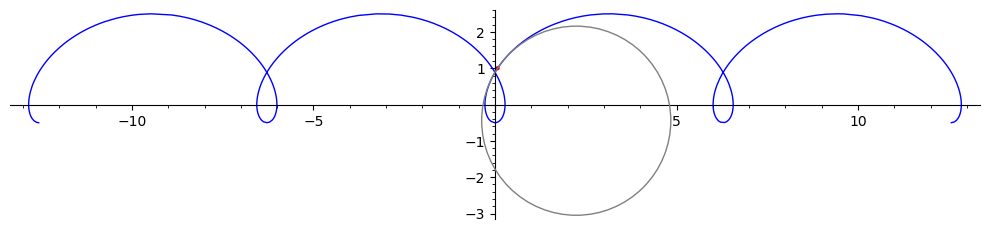

In [22]:
teta = pi/2
Mteta = D(teta)
v = derivee_vectorielle(D)
vteta = v(teta)
Tteta = vteta/vteta.norm()
Nteta = J(Tteta)
k = courbure_algebrique(D)
kteta = k(teta)
rteta = 1/kteta

C_D = Mteta + rteta * Nteta

Cercle_D = parametric_plot(D,(t, -4*pi,4*pi)) + circle(C_D,abs(rteta), color='grey') + point(D(pi/2), color = 'red')
Cercle_D.show(figsize = 10)

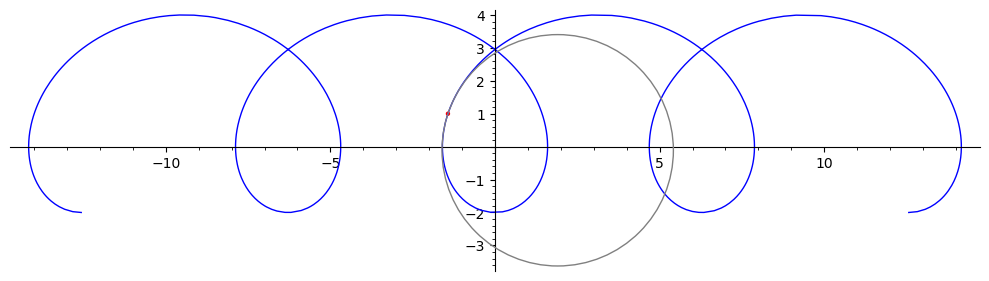

In [23]:
teta = pi/2
Mteta = E(teta)
v = derivee_vectorielle(E)
vteta = v(teta)
Tteta = vteta/vteta.norm()
Nteta = J(Tteta)
k = courbure_algebrique(E)
kteta = k(teta)
rteta = 1/kteta

C_E = Mteta + rteta * Nteta

Cercle_E = parametric_plot(E,(t, -4*pi,4*pi)) + circle(C_E,abs(rteta), color='grey') + point(E(pi/2), color = 'red')
Cercle_E.show(figsize = 10)

## Lemniscates

Voici une fonction donnant la lemniscate de paramètre `a`.

In [24]:
def lemniscate(a):
    r"""
    Renvoie la lemniscate de paramètre `a`.

    EXAMPLES:

    La lemniscate de paramètre 1::

        sage: M = lemniscate(1)
        sage: M
        t |--> (cos(t)/(sin(t)^2 + 1), cos(t)*sin(t)/(sin(t)^2 + 1))
    """
    M(t) = (a * cos(t) / (1 + sin(t)^2), a * sin(t) * cos(t) / (1 + sin(t)^2))
    return M

> **Exercice.**
>
> Tracer les lemniscates de différents paramètres.
>
> Pour `a = 1`, calculer la courbure de la lemniscate en fonction du temps.
>
> Tracer le cercle osculateur en quelques points de la courbe.


In [25]:
L1 = lemniscate(1)
L1

t |--> (cos(t)/(sin(t)^2 + 1), cos(t)*sin(t)/(sin(t)^2 + 1))

In [26]:
L2 = lemniscate(2)
L2

t |--> (2*cos(t)/(sin(t)^2 + 1), 2*cos(t)*sin(t)/(sin(t)^2 + 1))

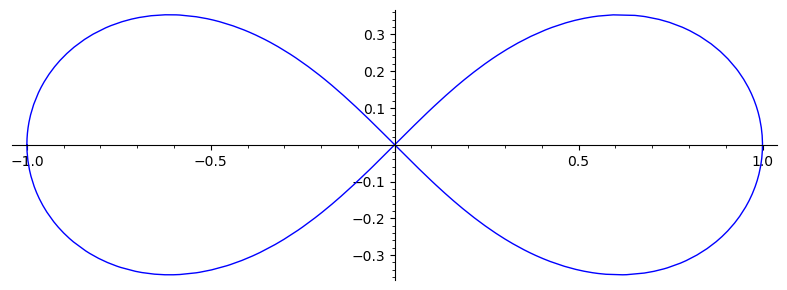

In [27]:
Courbe_L1 = parametric_plot(L1,(-pi,pi), color = 'blue')
Courbe_L1.show(figsize = 8, aspect_ratio = 1)

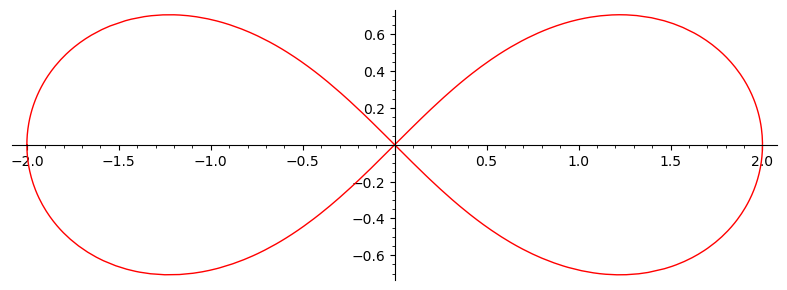

In [28]:
Courbe_L2 = parametric_plot(L2,(-pi,pi), color = 'red')
Courbe_L2.show(figsize = 8, aspect_ratio = 1)

In [29]:
Courbe_Algebrique_Lemniscate_1 = courbure_algebrique(L1)
Courbe_Algebrique_Lemniscate_1

t |--> ((2*cos(t)^2*sin(t)^2/(sin(t)^2 + 1)^2 - cos(t)^2/(sin(t)^2 + 1) + sin(t)^2/(sin(t)^2 + 1))*(8*cos(t)^3*sin(t)^2/(sin(t)^2 + 1)^3 - 2*cos(t)^3/(sin(t)^2 + 1)^2 + 6*cos(t)*sin(t)^2/(sin(t)^2 + 1)^2 - cos(t)/(sin(t)^2 + 1)) - 2*(4*cos(t)^3*sin(t)^3/(sin(t)^2 + 1)^3 - 3*cos(t)^3*sin(t)/(sin(t)^2 + 1)^2 + 3*cos(t)*sin(t)^3/(sin(t)^2 + 1)^2 - 2*cos(t)*sin(t)/(sin(t)^2 + 1))*(2*cos(t)^2*sin(t)/(sin(t)^2 + 1)^2 + sin(t)/(sin(t)^2 + 1)))/((2*cos(t)^2*sin(t)^2/(sin(t)^2 + 1)^2 - cos(t)^2/(sin(t)^2 + 1) + sin(t)^2/(sin(t)^2 + 1))^2 + (2*cos(t)^2*sin(t)/(sin(t)^2 + 1)^2 + sin(t)/(sin(t)^2 + 1))^2)^(3/2)

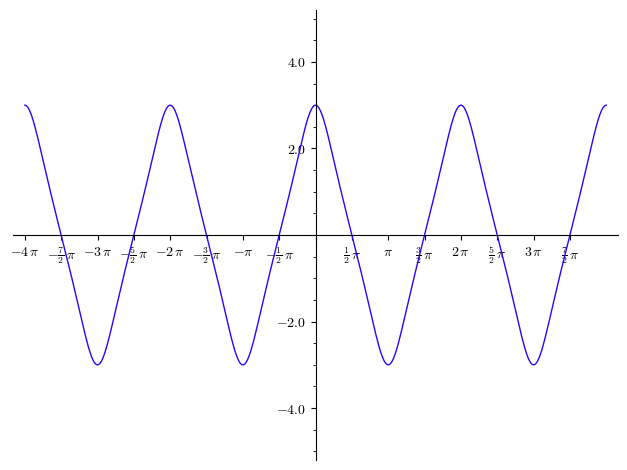

In [30]:
plot(courbure_algebrique(L1),(-4*pi,4*pi), xmin = -15, xmax = 15, ymin = -5, ymax = 5, hue=0.7
    , ticks=[srange(-4*pi, 4*pi, pi/2), None], tick_formatter=pi)

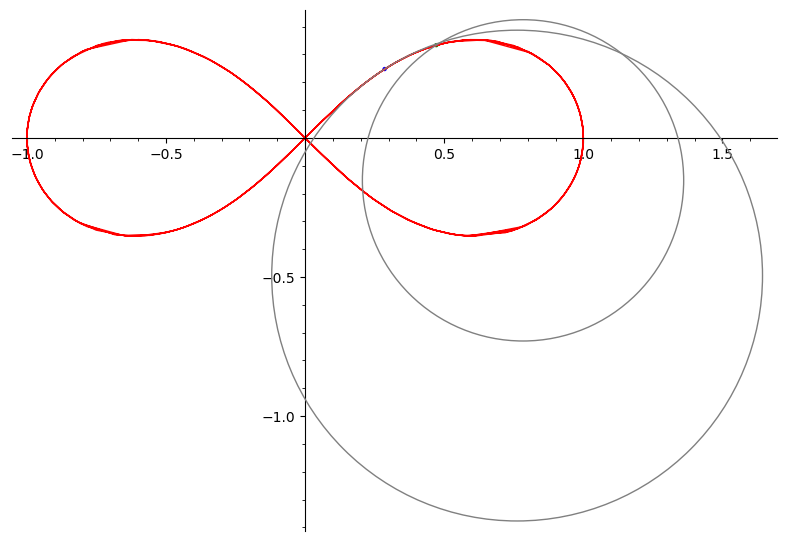

In [32]:
teta = pi/3
Mteta = L1(teta)
v = derivee_vectorielle(L1)
vteta = v(teta)
Tteta = vteta/vteta.norm()
Nteta = J(Tteta)
k = courbure_algebrique(L1)
kteta = k(teta)
rteta = 1/kteta

teta1 = pi/4
Mteta1 = L1(teta1)
v1 = derivee_vectorielle(L1)
vteta1 = v1(teta)
Tteta1 = vteta1/vteta1.norm()
Nteta1 = J(Tteta1)
k1 = courbure_algebrique(L1)
kteta1 = k(teta1)
rteta1 = 1/kteta1

C_L1 = Mteta + rteta * Nteta
C_L1_1 = Mteta1 + rteta1 * Nteta1

Cercle_L1 = parametric_plot(L1,(-4*pi,4*pi), color ='red') + circle(C_L1,abs(rteta), color='grey') + point(L1(pi/3), color = 'blue') + circle(C_L1_1,abs(rteta1), color='grey') + point(L1(pi/4), color = 'green')
Cercle_L1.show(figsize = 8)